# Day 21 of ML 30-Days Challenge

# Task

**Model Evaluation Metrics (Classification)**: Learn about Confusion Matrix, Accuracy, Precision, Recall, and F1-Score. Explore the ROC curve and AUC score to evaluate a model's performance across all classification thresholds.

In [23]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
)
import matplotlib.pyplot as plt

###1. Create a 200-row dataset

In [24]:
X, y = make_classification(
    n_samples=200,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_clusters_per_class=2,
    weights=[0.55, 0.45],
    class_sep=1.2,
    random_state=43
)

feature_names = [f"feature_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

###2. Train/test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split( df[feature_names], df["target"], test_size=0.25, random_state=42, stratify=df["target"] )

###3. Train a classifier (Logistic Regression)

In [26]:
clf = LogisticRegression(max_iter=1000, solver="lbfgs")
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

###4. Predictions

In [27]:
y_pred = clf.predict(X_test)

###5. Confusion Matrix

In [28]:
cm = confusion_matrix(y_test, y_pred)

###6. Key Metrics Scores

In [29]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")

# Shortcut text summary
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.980
Precision: 1.000
Recall: 0.957
F1-score: 0.978

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       1.00      0.96      0.98        23

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



###7. ROC Curve and AUC

In [30]:
probs = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)
print(f"ROC AUC: {auc_score:.3f}")

ROC AUC: 0.957


###8. Single combined visualization: Confusion Matrix + ROC Curve

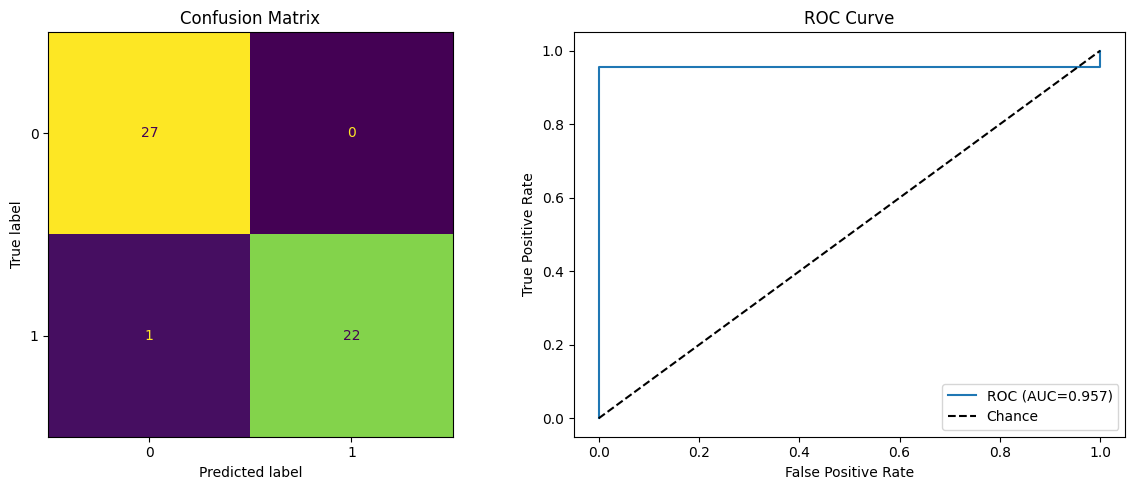

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix plot
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
cmd.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# ROC Curve plot
axes[1].plot(fpr, tpr, label=f"ROC (AUC={auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Chance")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()